In [3]:
from pathlib import Path
import polars as pl

parquet_path = Path("/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons.parquet")

df_small = pl.scan_parquet(parquet_path).limit(3).collect()

print("Rows loaded:", df_small.height)
print("Columns:")
for c in df_small.columns:
    print(" ", c)

print("\nSchema:")
print(df_small.schema)

Rows loaded: 3
Columns:
  event_id
  particle_id
  truth_energy
  truth_px
  truth_py
  truth_pz
  truth_p
  truth_pt
  truth_eta
  truth_phi
  truth_charge
  n_cells
  cell_x
  cell_y
  cell_z
  cell_eta
  cell_phi
  cell_e_total
  cell_e_calibrated
  cell_detector
  cell_t_from_e
  cell_e_from_e
  cell_e_from_e_cal
  cell_dR_truth
  split

Schema:
Schema([('event_id', Int64), ('particle_id', Int64), ('truth_energy', Float64), ('truth_px', Float64), ('truth_py', Float64), ('truth_pz', Float64), ('truth_p', Float64), ('truth_pt', Float64), ('truth_eta', Float64), ('truth_phi', Float64), ('truth_charge', Int64), ('n_cells', Int64), ('cell_x', List(Float64)), ('cell_y', List(Float64)), ('cell_z', List(Float64)), ('cell_eta', List(Float64)), ('cell_phi', List(Float64)), ('cell_e_total', List(Float64)), ('cell_e_calibrated', List(Float64)), ('cell_detector', List(Int64)), ('cell_t_from_e', List(Float64)), ('cell_e_from_e', List(Float64)), ('cell_e_from_e_cal', List(Float64)), ('cell_dR_tru

In [5]:
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt


def wrap_phi(phi):
    return np.arctan2(np.sin(phi), np.cos(phi))


def xyz_to_eta_phi(x, y, z):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(r, z)

    # Avoid log/tan numerical problems exactly at theta = 0
    theta = np.clip(theta, 1e-12, np.pi - 1e-12)

    eta = -np.log(np.tan(theta / 2.0))
    phi = np.arctan2(y, x)

    return eta, phi


def collect_from_processed_parquet(
    parquet_path="data/electrons/electrons.parquet",
    split="test",
    max_electrons=100,
    max_hits_per_electron=150,
    max_total_hits=10000,
    seed=0,
):
    rng = np.random.default_rng(seed)

    scan = pl.scan_parquet(parquet_path)

    if "split" in pl.read_parquet(parquet_path, n_rows=1).columns:
        scan = scan.filter(pl.col("split") == split)

    df = scan.limit(max_electrons).collect()

    all_hit_eta = []
    all_hit_phi = []
    all_particle_eta = []
    all_particle_phi = []
    all_energy = []

    total_hits = 0

    for row in df.iter_rows(named=True):
        x = np.asarray(row["cell_x"], dtype=float)
        y = np.asarray(row["cell_y"], dtype=float)
        z = np.asarray(row["cell_z"], dtype=float)

        n = len(x)
        if n == 0:
            continue

        if n > max_hits_per_electron:
            keep = rng.choice(n, size=max_hits_per_electron, replace=False)
        else:
            keep = np.arange(n)

        x = x[keep]
        y = y[keep]
        z = z[keep]

        hit_eta, hit_phi = xyz_to_eta_phi(x, y, z)

        particle_eta = float(row["truth_eta"])
        particle_phi = float(row["truth_phi"])

        n_keep = len(hit_eta)

        all_hit_eta.append(hit_eta)
        all_hit_phi.append(wrap_phi(hit_phi))
        all_particle_eta.append(np.full(n_keep, particle_eta))
        all_particle_phi.append(np.full(n_keep, wrap_phi(particle_phi)))

        if "cell_e_calibrated" in row:
            energy = np.asarray(row["cell_e_calibrated"], dtype=float)[keep]
        elif "cell_e_total" in row:
            energy = np.asarray(row["cell_e_total"], dtype=float)[keep]
        else:
            energy = np.ones(n_keep)

        all_energy.append(energy)

        total_hits += n_keep
        if total_hits >= max_total_hits:
            break

    return {
        "hit_eta": np.concatenate(all_hit_eta),
        "hit_phi": np.concatenate(all_hit_phi),
        "particle_eta": np.concatenate(all_particle_eta),
        "particle_phi": np.concatenate(all_particle_phi),
        "energy": np.concatenate(all_energy),
    }


data = collect_from_processed_parquet(
    parquet_path="/Users/loiclambert/code/colliderml-electron-calo/data/electrons/electrons.parquet",
    split="test",
    max_electrons=100,
    max_hits_per_electron=150,
    max_total_hits=10000,
)

print("Hits collected:", len(data["hit_eta"]))

Hits collected: 10037


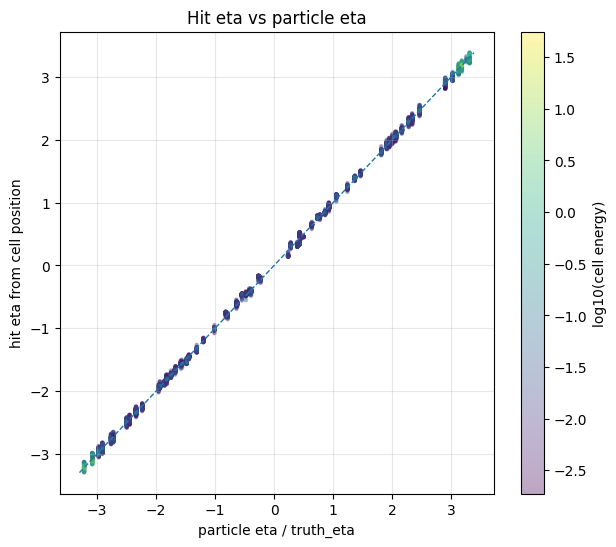

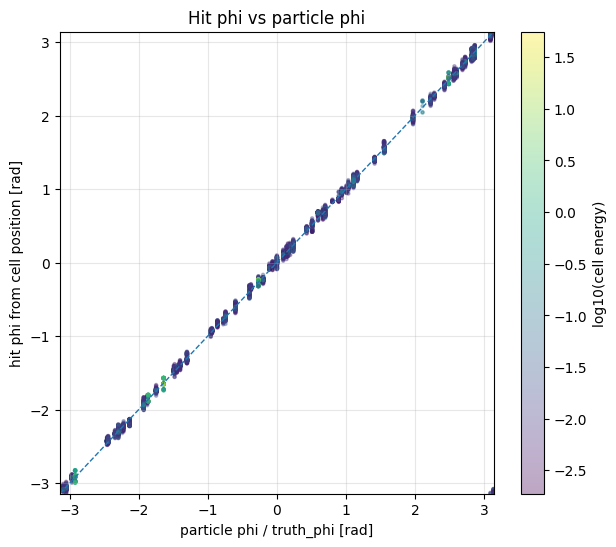

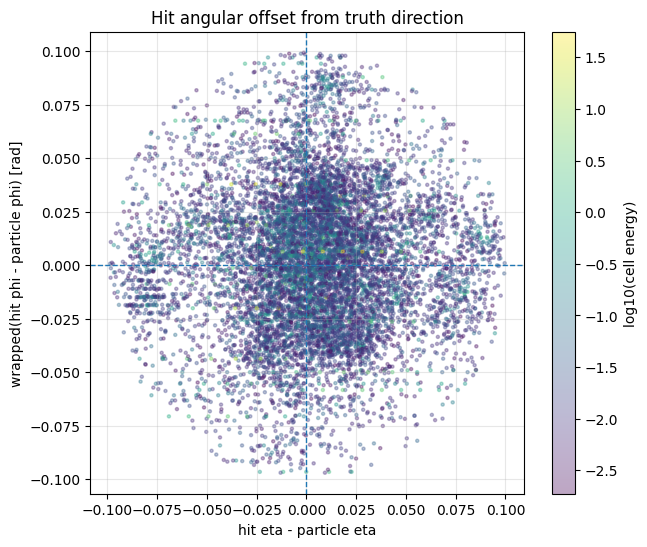

In [6]:
hit_eta = data["hit_eta"]
hit_phi = data["hit_phi"]
particle_eta = data["particle_eta"]
particle_phi = data["particle_phi"]
energy = data["energy"]

color_value = np.log10(np.clip(energy, 1e-12, None))


plt.figure(figsize=(7, 6))
plt.scatter(
    particle_eta,
    hit_eta,
    c=color_value,
    s=5,
    alpha=0.35,
)

eta_min = min(particle_eta.min(), hit_eta.min())
eta_max = max(particle_eta.max(), hit_eta.max())

plt.plot(
    [eta_min, eta_max],
    [eta_min, eta_max],
    linestyle="--",
    linewidth=1,
)

plt.xlabel("particle eta / truth_eta")
plt.ylabel("hit eta from cell position")
plt.title("Hit eta vs particle eta")
plt.colorbar(label="log10(cell energy)")
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(7, 6))
plt.scatter(
    particle_phi,
    hit_phi,
    c=color_value,
    s=5,
    alpha=0.35,
)

plt.plot(
    [-np.pi, np.pi],
    [-np.pi, np.pi],
    linestyle="--",
    linewidth=1,
)

plt.xlabel("particle phi / truth_phi [rad]")
plt.ylabel("hit phi from cell position [rad]")
plt.title("Hit phi vs particle phi")
plt.colorbar(label="log10(cell energy)")
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.grid(alpha=0.3)
plt.show()


delta_eta = hit_eta - particle_eta
delta_phi = wrap_phi(hit_phi - particle_phi)

plt.figure(figsize=(7, 6))
plt.scatter(
    delta_eta,
    delta_phi,
    c=color_value,
    s=5,
    alpha=0.35,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("hit eta - particle eta")
plt.ylabel("wrapped(hit phi - particle phi) [rad]")
plt.title("Hit angular offset from truth direction")
plt.colorbar(label="log10(cell energy)")
plt.grid(alpha=0.3)
plt.show()